# keys import

In [6]:
import os
from dotenv import load_dotenv
# 1. Load variables from the .env file
load_dotenv()
OLLAMA_API_KEY = os.environ.get("OLLAMA_API_KEY")
GOOGLE_API_KEY = os.environ.get("GOOGLE_API_KEY")
TAVILY_API_KEY = os.environ.get("TAVILY_API_KEY")

# Model Loading

In [ ]:
import os
from langchain_ollama import ChatOllama
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_tavily import TavilySearch  # updated at 1.0

#llm
##################
llm = ChatOllama(
    model="nemotron-3-super:cloud",
    base_url="https://ollama.com",
    client_kwargs={"headers": {"Authorization": f"Bearer {OLLAMA_API_KEY}"}},
)
response = llm.invoke("What is the color of the sky answer in one word?")
print(response.content)

# llm
####################
# Initialize the model (you can use models like gemini-2.5-flash or gemini-pro)
llmg = ChatGoogleGenerativeAI(model="gemini-2.5-flash", google_api_key=GOOGLE_API_KEY)
response = llmg.invoke("What is the color of the sky answer in one word?")
print(response.content)



# tool interactions

In [ ]:
# tool
##############
tavily_search = TavilySearch(max_results=3,tavily_api_key=TAVILY_API_KEY)
data = tavily_search.invoke({"query": "What is LangGraph?"})
search_docs = data.get("results", data)

# 2. Bind the tool directly to your LLM
llm_with_tools = llm.bind_tools([tavily_tool])

# custom tool 
###################
def multiply(a: int, b: int) -> int:
    """Multiply a and b."""
    return a * b

llm_with_tools = llm.bind_tools([multiply])


# tool binding
from langchain.tools import tool
@tool
def write_email(to: str, subject: str, content: str) -> str:
    """Write and send an email."""
    # Placeholder response - in real app would send email
    return f"Email sent to {to} with subject '{subject}' and content: {content}"


In [7]:
# tool binding
from langchain.tools import tool
@tool
def write_email(to: str, subject: str, content: str) -> str:
    """Write and send an email."""
    # Placeholder response - in real app would send email
    return f"Email sent to {to} with subject '{subject}' and content: {content}"

In [8]:
type(write_email)

langchain_core.tools.structured.StructuredTool

In [9]:
write_email.args

{'to': {'title': 'To', 'type': 'string'},
 'subject': {'title': 'Subject', 'type': 'string'},
 'content': {'title': 'Content', 'type': 'string'}}

In [10]:
@tool
def multiply(a: int, b: int) -> int:
    """Multiply a and b."""
    return a * b

In [11]:
multiply.args

{'a': {'title': 'A', 'type': 'integer'},
 'b': {'title': 'B', 'type': 'integer'}}

In [12]:
multiply.description

'Multiply a and b.'

In [16]:
from rich.markdown import Markdown
Markdown(write_email.description)

Write and send an email.

# email tool interaction with llm 

In [ ]:
# tool binding
from langchain.tools import tool
@tool
def write_email(to: str, subject: str, content: str) -> str:
    """Write and send an email."""
    # Placeholder response - in real app would send email
    return f"Email sent to {to} with subject '{subject}' and content: {content}"


# Connect tools to a chat model
model_with_tools = llm.bind_tools([write_email])

# The model will now be able to call tools
output = model_with_tools.invoke("Draft a response to my boss (boss@company.ai) about tomorrow's meeting")

In [ ]:
output

AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'nemotron-3-super:cloud', 'created_at': '2026-06-02T14:51:18.924411929Z', 'done': True, 'done_reason': 'stop', 'total_duration': 4271372974, 'load_duration': None, 'prompt_eval_count': 329, 'prompt_eval_duration': None, 'eval_count': 478, 'eval_duration': None, 'logprobs': None, 'model_name': 'nemotron-3-super:cloud', 'model_provider': 'ollama'}, id='lc_run--019e88d9-7cdb-7cd0-8e44-4bb9ef096ef5-0', tool_calls=[{'name': 'write_email', 'args': {'to': 'boss@company.ai', 'subject': "Re: Tomorrow's Meeting", 'content': "Hi,\n\nThank you for scheduling tomorrow's meeting. I'll be there and ready to contribute. Please let me know if you need anything from me before then or if there's a specific agenda I should review.\n\nBest regards,\n[Your Name]"}, 'id': '51a16971-d595-404c-8aa0-ff12508a99ba', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 329, 'output_tokens': 478, 'total_tokens': 807})

In [24]:
type(output)

langchain_core.messages.ai.AIMessage

In [27]:
# Assuming your message object is named 'response'
response_dict = output.dict()

# Print each main attribute and its value
for key, value in response_dict.items():
    print(f"🔑 {key}:")
    print(f"   {value}")
    print("-" * 40)


🔑 content:
   
----------------------------------------
🔑 additional_kwargs:
   {}
----------------------------------------
🔑 response_metadata:
   {'model': 'nemotron-3-super:cloud', 'created_at': '2026-06-02T14:51:18.924411929Z', 'done': True, 'done_reason': 'stop', 'total_duration': 4271372974, 'load_duration': None, 'prompt_eval_count': 329, 'prompt_eval_duration': None, 'eval_count': 478, 'eval_duration': None, 'logprobs': None, 'model_name': 'nemotron-3-super:cloud', 'model_provider': 'ollama'}
----------------------------------------
🔑 type:
   ai
----------------------------------------
🔑 name:
   None
----------------------------------------
🔑 id:
   lc_run--019e88d9-7cdb-7cd0-8e44-4bb9ef096ef5-0
----------------------------------------
🔑 tool_calls:
   [{'name': 'write_email', 'args': {'to': 'boss@company.ai', 'subject': "Re: Tomorrow's Meeting", 'content': "Hi,\n\nThank you for scheduling tomorrow's meeting. I'll be there and ready to contribute. Please let me know if you ne

C:\Users\smrit\AppData\Local\Temp\ipykernel_15568\1530141790.py:2: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.13/migration/
  response_dict = output.dict()


In [29]:
output.tool_calls

[{'name': 'write_email',
  'args': {'to': 'boss@company.ai',
   'subject': "Re: Tomorrow's Meeting",
   'content': "Hi,\n\nThank you for scheduling tomorrow's meeting. I'll be there and ready to contribute. Please let me know if you need anything from me before then or if there's a specific agenda I should review.\n\nBest regards,\n[Your Name]"},
  'id': '51a16971-d595-404c-8aa0-ff12508a99ba',
  'type': 'tool_call'}]

## Extract tool calls and execute them

In [30]:
# Extract tool calls and execute them
args = output.tool_calls[0]['args']
args

{'to': 'boss@company.ai',
 'subject': "Re: Tomorrow's Meeting",
 'content': "Hi,\n\nThank you for scheduling tomorrow's meeting. I'll be there and ready to contribute. Please let me know if you need anything from me before then or if there's a specific agenda I should review.\n\nBest regards,\n[Your Name]"}

## Call the tool

In [31]:
# Call the tool
result = write_email.invoke(args)
Markdown(result)

Email sent to boss@company.ai with subject 'Re: Tomorrow's Meeting' and content: Hi,                               

Thank you for scheduling tomorrow's meeting. I'll be there and ready to contribute. Please let me know if you need 
anything from me before then or if there's a specific agenda I should review.                                      

Best regards, [Your Name]

# with Langraph

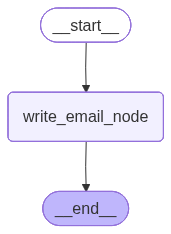

In [36]:
# define state
#####################
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

class StateSchema(TypedDict):
    request: str
    email: str


# create node
####################
def write_email_node(state: StateSchema) -> StateSchema:
    # Imperative code that processes the request
    output = model_with_tools.invoke(state["request"])
    args = output.tool_calls[0]['args']
    email = write_email.invoke(args)
    return {"email": email}


# add nodes and edges
#######################
workflow = StateGraph(StateSchema)
workflow.add_node("write_email_node", write_email_node)
workflow.add_edge(START, "write_email_node")
workflow.add_edge("write_email_node", END)

app = workflow.compile()

# Show
from IPython.display import Image, display
display(Image(app.get_graph(xray=True).draw_mermaid_png()))



In [ ]:
app.invoke({"request": "Draft a response to my boss (boss@company.ai) about tomorrow's meeting"})

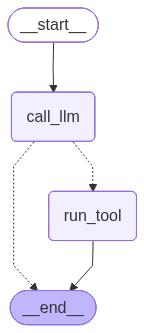

In [38]:
from typing import Literal
from langgraph.graph import MessagesState
# from email_assistant.utils import show_graph

def call_llm(state: MessagesState) -> MessagesState:
    """Run LLM"""

    output = model_with_tools.invoke(state["messages"])
    return {"messages": [output]}

def run_tool(state: MessagesState):
    """Performs the tool call"""

    result = []
    for tool_call in state["messages"][-1].tool_calls:
        observation = write_email.invoke(tool_call["args"])
        result.append({"role": "tool", "content": observation, "tool_call_id": tool_call["id"]})
    return {"messages": result}

def should_continue(state: MessagesState) -> Literal["run_tool", "__end__"]:
    """Route to tool handler, or end if Done tool called"""
    
    # Get the last message
    messages = state["messages"]
    last_message = messages[-1]
    
    # If the last message is a tool call, check if it's a Done tool call
    if last_message.tool_calls:
        return "run_tool"
    # Otherwise, we stop (reply to the user)
    return END

workflow = StateGraph(MessagesState)
workflow.add_node("call_llm", call_llm)
workflow.add_node("run_tool", run_tool)
workflow.add_edge(START, "call_llm")
workflow.add_conditional_edges("call_llm", should_continue, {"run_tool": "run_tool", END: END})
workflow.add_edge("run_tool", END)

# Run the workflow
app = workflow.compile()
display(Image(app.get_graph(xray=True).draw_mermaid_png()))

In [39]:
result = app.invoke({"messages": [{"role": "user", "content": "Draft a response to my boss (boss@company.ai) confirming that I want to attend Interrupt!"}]})
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

Draft a response to my boss (boss@company.ai) confirming that I want to attend Interrupt!
================================== Ai Message ==================================
Tool Calls:
  write_email (5722521f-7a67-4357-bb83-b29556dec2f1)
 Call ID: 5722521f-7a67-4357-bb83-b29556dec2f1
  Args:
    to: boss@company.ai
    subject: Confirmation of Attendance: Interrupt!
    content: Hi,

Thank you for the invitation to attend Interrupt!. I am pleased to confirm that I will be attending the event.

Please let me know if there are any pre-event preparations, materials to review, or logistical details I should be aware of.

I look forward to the event and appreciate the opportunity to participate.

Best regards,
[Your Name]
================================= Tool Message =================================

Email sent to boss@company.ai with subject 'Confirmation of Attendance: Interrupt!' and content: Hi,

Thank you

# interuppts

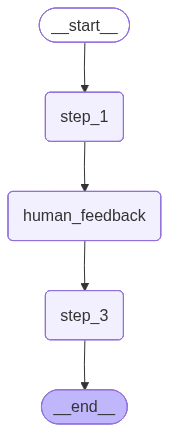

In [42]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

from langgraph.types import Command, interrupt
from langgraph.checkpoint.memory import InMemorySaver

class State(TypedDict):
    input: str
    user_feedback: str

def step_1(state):
    print("---Step 1---")
    pass

def human_feedback(state):
    print("---human_feedback---")
    feedback = interrupt("Please provide feedback:")
    return {"user_feedback": feedback}

def step_3(state):
    print("---Step 3---")
    pass

builder = StateGraph(State)
builder.add_node("step_1", step_1)
builder.add_node("human_feedback", human_feedback)
builder.add_node("step_3", step_3)
builder.add_edge(START, "step_1")
builder.add_edge("step_1", "human_feedback")
builder.add_edge("human_feedback", "step_3")
builder.add_edge("step_3", END)

# Set up memory
memory = InMemorySaver()

# Add
graph = builder.compile(checkpointer=memory)
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

In [43]:
# Input
initial_input = {"input": "hello world"}

# Thread
thread = {"configurable": {"thread_id": "1"}}

# Run the graph until the first interruption
for event in graph.stream(initial_input, thread, stream_mode="updates"):
    print(event)
    print("\n")

---Step 1---
{'step_1': None}


---human_feedback---
{'__interrupt__': (Interrupt(value='Please provide feedback:', id='973034c7ae2eb5586787f01a6b84d56a'),)}




In [44]:
# Continue the graph execution
for event in graph.stream(
    Command(resume="go to step 3!"),
    thread,
    stream_mode="updates",
):
    print(event)
    print("\n")

---human_feedback---
{'human_feedback': {'user_feedback': 'go to step 3!'}}


---Step 3---
{'step_3': None}




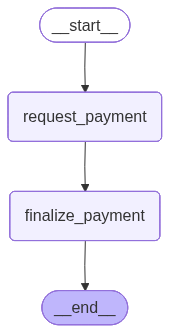

In [50]:
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.types import interrupt
from typing_extensions import TypedDict

# 1. Define Graph State
class State(TypedDict):
    payment_amount: int
    status: str

# 2. Define the Nodes
def request_payment(state: State):
    print(f"💰 Processing request for ₹{state['payment_amount']}...")
    
    # 🛑 THE INTERRUPT: Execution halts here. 
    # It sends a question to the user and waits for their response.
    user_response = interrupt(f"Do you approve paying ₹{state['payment_amount']}?")
    
    # Execution resumes here only AFTER the human responds
    return {"status": user_response}

def finalize_payment(state: State):
    if state["status"].lower() == "yes":
        print("✅ Money sent successfully!")
    else:
        print("❌ Payment cancelled by user.")
    return state

# 3. Build and compile the graph (Memory is REQUIRED for interrupts)
builder = StateGraph(State)
builder.add_node("request_payment", request_payment)
builder.add_node("finalize_payment", finalize_payment)

builder.add_edge(START, "request_payment")
builder.add_edge("request_payment", "finalize_payment")
builder.add_edge("finalize_payment", END)

memory = InMemorySaver()
graph = builder.compile(checkpointer=memory)

display(Image(graph.get_graph(xray=True).draw_mermaid_png()))


In [51]:
config = {"configurable": {"thread_id": "tx_999"}}
initial_state = {"payment_amount": 5000, "status": "pending"}

# Run until it hits the interrupt
events = graph.stream(initial_state, config, stream_mode="values")
for event in events:
    print(event)


{'payment_amount': 5000, 'status': 'pending'}
💰 Processing request for ₹5000...
{'payment_amount': 5000, 'status': 'pending', '__interrupt__': (Interrupt(value='Do you approve paying ₹5000?', id='bef7349ca160d87cd472ec184378f36f'),)}


In [ ]:
state_info = graph.get_state(config)
state_info


StateSnapshot(values={'payment_amount': 5000, 'status': 'pending'}, next=('request_payment',), config={'configurable': {'thread_id': 'tx_999', 'checkpoint_ns': '', 'checkpoint_id': '1f15e9ce-b183-66ec-8000-1cde4924bab9'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-06-02T16:05:47.733783+00:00', parent_config={'configurable': {'thread_id': 'tx_999', 'checkpoint_ns': '', 'checkpoint_id': '1f15e9ce-b13f-68e2-bfff-7363be3035d4'}}, tasks=(PregelTask(id='b29fc660-9b6b-6aa7-255d-74193ff1f8ea', name='request_payment', path=('__pregel_pull', 'request_payment'), error=None, interrupts=(Interrupt(value='Do you approve paying ₹5000?', id='bef7349ca160d87cd472ec184378f36f'),), state=None, result=None),), interrupts=(Interrupt(value='Do you approve paying ₹5000?', id='bef7349ca160d87cd472ec184378f36f'),))

In [69]:
state_info.tasks[0]

PregelTask(id='b29fc660-9b6b-6aa7-255d-74193ff1f8ea', name='request_payment', path=('__pregel_pull', 'request_payment'), error=None, interrupts=(Interrupt(value='Do you approve paying ₹5000?', id='bef7349ca160d87cd472ec184378f36f'),), state=None, result=None)

In [67]:
state_info.tasks[0].interrupts[0]

Interrupt(value='Do you approve paying ₹5000?', id='bef7349ca160d87cd472ec184378f36f')

In [59]:
# Assuming your snapshot variable is named 'snapshot'
print("📊 Graph State Values:")
for key, value in state_info.values.items():
    print(f"  {key}: {value}")


📊 Graph State Values:
  payment_amount: 5000
  status: pending


In [62]:

for interrupt in state_info.interrupts:
    print(f"  ID: {interrupt.id}")
    print(f"  Message: {interrupt.value}")


  ID: bef7349ca160d87cd472ec184378f36f
  Message: Do you approve paying ₹5000?


In [48]:
from langgraph.types import Command

# Provide the human response to resume the thread
events = graph.stream(Command(resume="yes"), config, stream_mode="values")
for event in events:
    print(event)


{'payment_amount': 5000, 'status': 'pending'}
💰 Processing request for ₹5000...
{'payment_amount': 5000, 'status': 'yes'}
✅ Money sent successfully!
{'payment_amount': 5000, 'status': 'yes'}


In [49]:
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.types import interrupt, Command
from typing_extensions import TypedDict

# 1. Define Graph State
class State(TypedDict):
    payment_amount: int
    status: str

# 2. Define the Nodes
def request_payment(state: State):
    print(f"\n[Node] Processing request for ₹{state['payment_amount']}...")
    
    # 🛑 The graph freezes here and waits for a resume command
    user_response = interrupt(f"Do you approve paying ₹{state['payment_amount']}? (yes/no): ")
    
    return {"status": user_response}

def finalize_payment(state: State):
    print("\n[Node] Finalizing transaction...")
    if state["status"].strip().lower() == "yes":
        print("✅ SUCCESS: Money sent successfully!")
    else:
        print("❌ CANCELLED: Payment declined by user.")
    return state

# 3. Build and Compile the Graph with Memory
builder = StateGraph(State)
builder.add_node("request_payment", request_payment)
builder.add_node("finalize_payment", finalize_payment)

builder.add_edge(START, "request_payment")
builder.add_edge("request_payment", "finalize_payment")
builder.add_edge("finalize_payment", END)

memory = InMemorySaver()
graph = builder.compile(checkpointer=memory)

# ==========================================
# 🔄 THE INTERACTIVE CHAT LOOP
# ==========================================

config = {"configurable": {"thread_id": "payment_session_1"}}
initial_input = {"payment_amount": 5000, "status": "pending"}

# This variable will hold our initial inputs or the human resume command
current_input = initial_input 

print("🚀 Starting LangGraph Payment Flow...")

while True:
    # 1. Run the graph with the current input (or resume command)
    for event in graph.stream(current_input, config, stream_mode="updates"):
        pass # Stream executes the nodes behind the scenes
    
    # 2. Check if the graph paused because of an interrupt
    state_info = graph.get_state(config)
    
    if state_info.tasks:
        # Fetch the interrupt message text we defined inside the node
        interrupt_msg = state_info.tasks[0].interrupts[0].value
        
        # Ask the user directly in the terminal
        human_choice = input(f"\n📢 HUMAN INTERVENTION REQUIRED: {interrupt_msg}")
        
        # Prepare the special Command object to pass the answer back into the graph
        current_input = Command(resume=human_choice)
    else:
        # No tasks left means the graph completed its run successfully!
        print("\n🏁 Graph finished execution.")
        break


🚀 Starting LangGraph Payment Flow...

[Node] Processing request for ₹5000...

[Node] Processing request for ₹5000...

[Node] Finalizing transaction...
✅ SUCCESS: Money sent successfully!

🏁 Graph finished execution.


In a chat loop, the thread_id acts as the glue that keeps an ongoing conversation connected, logical, and isolated [4].
Without it, the system would treat every single message you type as a brand-new conversation with a completely blank slate [4].
Here are the primary uses of a thread_id inside an interactive loop:
## 1. It Links History Across Iterations
A chat loop continuously spins (using a while True or for block). Every time you send human feedback or a new message, graph.stream() or graph.invoke() finishes and exits. The thread_id ensures that when the loop cycles back and starts the graph again, LangGraph loads the exact memory checkpoint from the previous cycle [4, 5].
## 2. It Targets the Correct "Paused" State
When your graph hits an interrupt(), it freezes and saves its state under that specific thread_id [5]. When the loop captures your input and sends back a Command(resume=...), the thread_id acts like a key—telling LangGraph: "Hey, look up the paused execution under this exact ID, wake it up, and feed this user's answer into it." [4, 5]
## 3. It Allows Multiple Independent Sessions
If you are building a chat application for multiple users, the thread_id ensures that User A and User B do not overwrite or see each other's data [4].

🔄 Chat Loop Session
├── Thread ID: "session_user_alice"  ➡️ Loads Alice's payment flow (₹5000)
└── Thread ID: "session_user_bob"    ➡️ Loads Bob's payment flow (₹200)

## 💻 Visualizing It in Code
Look at how the config containing your thread_id is passed into both functions inside your loop:

config = {"configurable": {"thread_id": "tx_999"}}
while True:
    # 1. Thread_id tells graph which historical memory to resume executing
    graph.stream(current_input, config=config)
    
    # 2. Thread_id tells graph WHICH snapshot to read to find the interrupt message
    state_info = graph.get_state(config=config)
    
    # ... handle input ...

If you want to scale this chat loop, let me know if you need to:

* Support multiple distinct users simultaneously in the loop
* Save the conversation to a database using SqliteSaver so the thread ID still works even if you stop and restart your Python script tomorrow
* Implement a "clear chat history" command that resets the thread ID on the fly


